In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Charger les CSV (adapter les chemins si besoin)
local1   = pd.read_csv("Local_1_part-00000-13421898-c004-45b8-86a9-0bc00436291f-c000.csv")
local2   = pd.read_csv("Local_2_part-00000-9994c4e4-e051-4955-8df4-425a0d3b146d-c000.csv")
cluster  = pd.read_csv("Cluster_part-00000-82f1ce7a-8153-46e0-8285-e0243352bc8b-c000.csv")

def parse_feature_set(comment: str) -> str | None:
    if not isinstance(comment, str):
        return None
    # Cas général : "dataset=D2, featureSet=with-weather, ..."
    m = re.search(r"featureSet=([a-zA-Z-]+)", comment)
    if m:
        return m.group(1)
    # Cas Local_2 : "local D2 article-weather lags=7 mois=201201 | ..."
    m = re.search(r"\b(no-weather|with-weather|article-weather)\b", comment)
    if m:
        return m.group(1)
    return None

for df in (local1, local2, cluster):
    df["feature_set"] = df["comment"].apply(parse_feature_set)

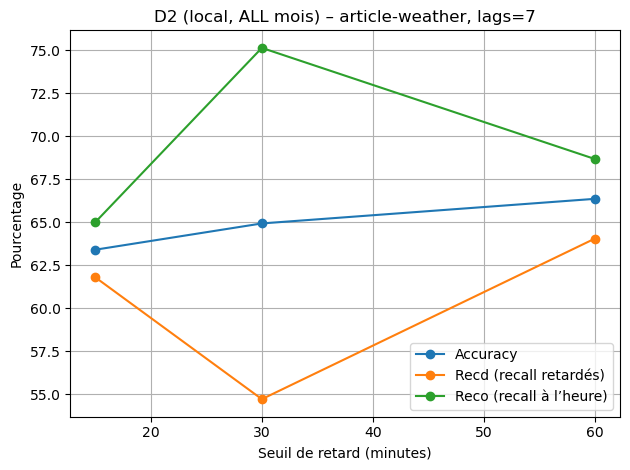

In [4]:
# D2, article-weather, lags=7, ALL mois
mask = (
    (local1["dataset_id"] == "D2") &
    (local1["feature_set"] == "article-weather") &
    (local1["lags"] == 7)
)

g1 = (local1[mask]
      .groupby("delay_threshold_min")[["test_accuracy",
                                       "test_recall_pos",
                                       "test_specificity"]]
      .mean()
      .reset_index())

# Passage en %
g1["test_accuracy"]    *= 100
g1["test_recall_pos"]  *= 100
g1["test_specificity"] *= 100

fig, ax = plt.subplots()
ax.plot(g1["delay_threshold_min"], g1["test_accuracy"],    marker="o", label="Accuracy")
ax.plot(g1["delay_threshold_min"], g1["test_recall_pos"],  marker="o", label="Recd (recall retardés)")
ax.plot(g1["delay_threshold_min"], g1["test_specificity"], marker="o", label="Reco (recall à l’heure)")

ax.set_xlabel("Seuil de retard (minutes)")
ax.set_ylabel("Pourcentage")
ax.set_title("D2 (local, ALL mois) – article-weather, lags=7")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

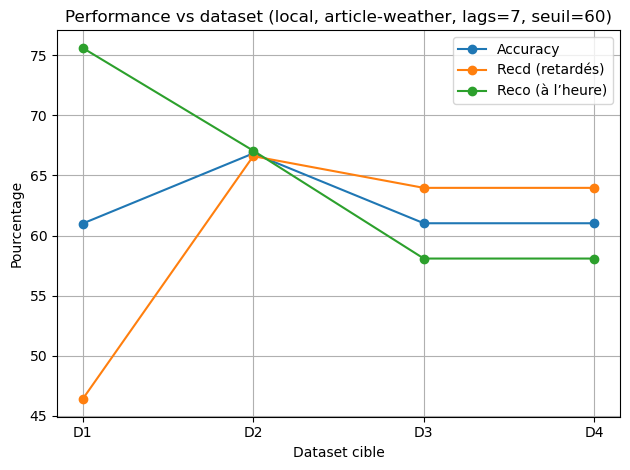

In [5]:
# D1..D4, article-weather, lags=7, seuil=60
mask = (
    (local1["feature_set"] == "article-weather") &
    (local1["lags"] == 7) &
    (local1["delay_threshold_min"] == 60)
)

tmp = local1[mask].copy()
# On garde, pour chaque dataset, le run avec le plus grand n_train
tmp = (tmp.sort_values(["dataset_id", "n_train"], ascending=[True, False])
          .groupby("dataset_id")
          .head(1))

g2 = tmp[["dataset_id", "test_accuracy",
          "test_recall_pos", "test_specificity"]].copy()
for col in ["test_accuracy", "test_recall_pos", "test_specificity"]:
    g2[col] *= 100

fig, ax = plt.subplots()
x = range(len(g2))
ax.plot(x, g2["test_accuracy"],    marker="o", label="Accuracy")
ax.plot(x, g2["test_recall_pos"],  marker="o", label="Recd (retardés)")
ax.plot(x, g2["test_specificity"], marker="o", label="Reco (à l’heure)")

ax.set_xticks(list(x))
ax.set_xticklabels(g2["dataset_id"])
ax.set_xlabel("Dataset cible")
ax.set_ylabel("Pourcentage")
ax.set_title("Performance vs dataset (local, article-weather, lags=7, seuil=60)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

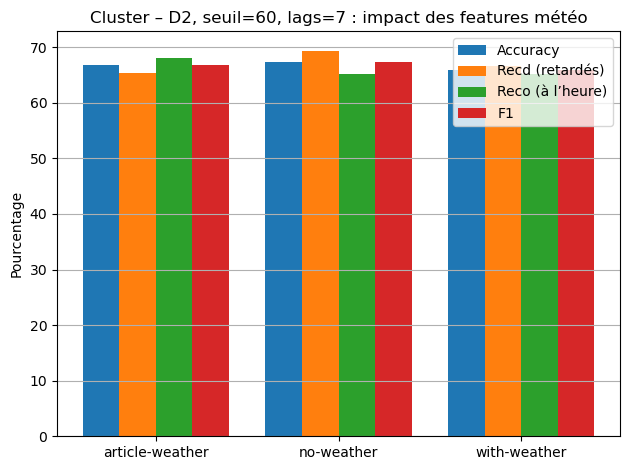

In [6]:
# D2, cluster, agrégation par feature_set
d2 = cluster[(cluster["dataset_id"] == "D2") & cluster["feature_set"].notna()]

g3 = (d2
      .groupby("feature_set")[["test_accuracy",
                               "test_recall_pos",
                               "test_specificity",
                               "test_f1"]]
      .mean()
      .reset_index())

# Pourcentages
for col in ["test_accuracy", "test_recall_pos", "test_specificity", "test_f1"]:
    g3[col] *= 100

metrics = ["test_accuracy", "test_recall_pos", "test_specificity", "test_f1"]
labels  = ["Accuracy", "Recd (retardés)", "Reco (à l’heure)", "F1"]
x = range(len(g3))
width = 0.2

fig, ax = plt.subplots()

for i, (m, lab) in enumerate(zip(metrics, labels)):
    offsets = [xi + (i - 1.5)*width for xi in x]
    ax.bar(offsets, g3[m], width, label=lab)

ax.set_xticks(list(x))
ax.set_xticklabels(g3["feature_set"])
ax.set_ylabel("Pourcentage")
ax.set_title("Cluster – D2, seuil=60, lags=7 : impact des features météo")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

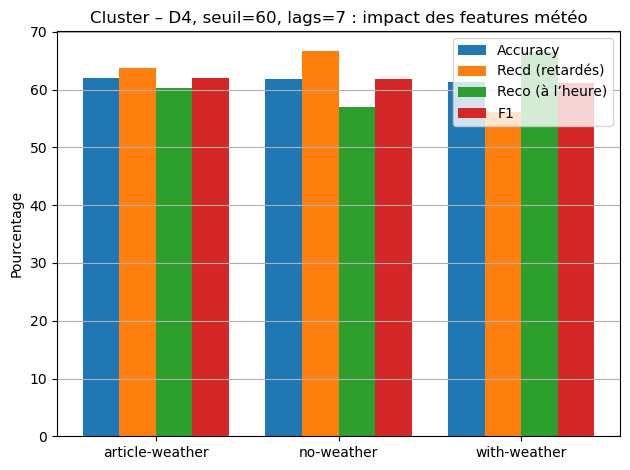

In [7]:
d4 = cluster[(cluster["dataset_id"] == "D4") & cluster["feature_set"].notna()]

g4 = (d4
      .groupby("feature_set")[["test_accuracy",
                               "test_recall_pos",
                               "test_specificity",
                               "test_f1"]]
      .mean()
      .reset_index())

for col in ["test_accuracy", "test_recall_pos", "test_specificity", "test_f1"]:
    g4[col] *= 100

metrics = ["test_accuracy", "test_recall_pos", "test_specificity", "test_f1"]
labels  = ["Accuracy", "Recd (retardés)", "Reco (à l’heure)", "F1"]
x = range(len(g4))
width = 0.2

fig, ax = plt.subplots()

for i, (m, lab) in enumerate(zip(metrics, labels)):
    offsets = [xi + (i - 1.5)*width for xi in x]
    ax.bar(offsets, g4[m], width, label=lab)

ax.set_xticks(list(x))
ax.set_xticklabels(g4["feature_set"])
ax.set_ylabel("Pourcentage")
ax.set_title("Cluster – D4, seuil=60, lags=7 : impact des features météo")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

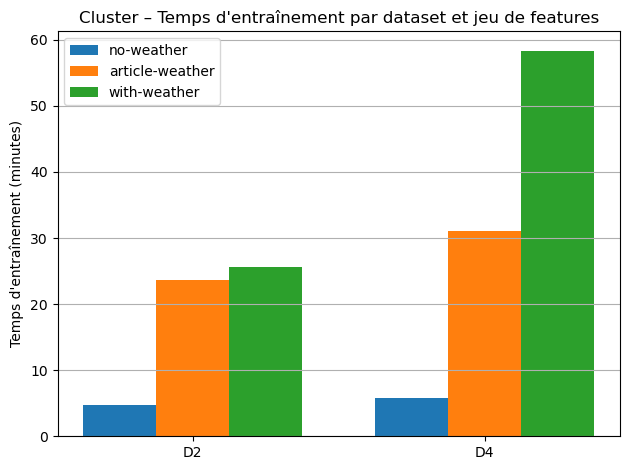

In [8]:
# Agrégation temps d'entraînement pour D2 et D4
def avg_train_time(df, dataset_id):
    sub = df[(df["dataset_id"] == dataset_id) & df["feature_set"].notna()]
    return (sub.groupby("feature_set")[["train_wall_time_sec"]]
               .mean()
               .reset_index()
               .assign(dataset_id=dataset_id))

d2_time = avg_train_time(cluster, "D2")
d4_time = avg_train_time(cluster, "D4")
time_df = pd.concat([d2_time, d4_time], ignore_index=True)

# Conversion en minutes
time_df["train_minutes"] = time_df["train_wall_time_sec"] / 60.0

fig, ax = plt.subplots()

datasets = ["D2", "D4"]
feature_sets = ["no-weather", "article-weather", "with-weather"]
width = 0.25
x = range(len(datasets))

for i, fs in enumerate(feature_sets):
    vals = []
    for ds in datasets:
        v = time_df[(time_df["dataset_id"] == ds) &
                    (time_df["feature_set"] == fs)]["train_minutes"].iloc[0]
        vals.append(v)
    offsets = [xi + (i - 1)*width for xi in x]
    ax.bar(offsets, vals, width, label=fs)

ax.set_xticks(list(x))
ax.set_xticklabels(datasets)
ax.set_ylabel("Temps d'entraînement (minutes)")
ax.set_title("Cluster – Temps d'entraînement par dataset et jeu de features")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

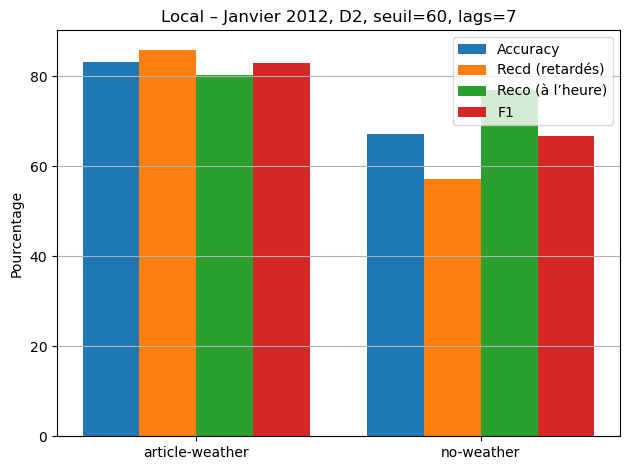

In [9]:
gA1 = local2[["feature_set", "test_accuracy",
              "test_recall_pos", "test_specificity", "test_f1"]].copy()

for col in ["test_accuracy", "test_recall_pos", "test_specificity", "test_f1"]:
    gA1[col] *= 100

metrics = ["test_accuracy", "test_recall_pos", "test_specificity", "test_f1"]
labels  = ["Accuracy", "Recd (retardés)", "Reco (à l’heure)", "F1"]
x = range(len(gA1))
width = 0.2

fig, ax = plt.subplots()

for i, (m, lab) in enumerate(zip(metrics, labels)):
    offsets = [xi + (i - 1.5)*width for xi in x]
    ax.bar(offsets, gA1[m], width, label=lab)

ax.set_xticks(list(x))
ax.set_xticklabels(gA1["feature_set"])
ax.set_ylabel("Pourcentage")
ax.set_title("Local – Janvier 2012, D2, seuil=60, lags=7")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

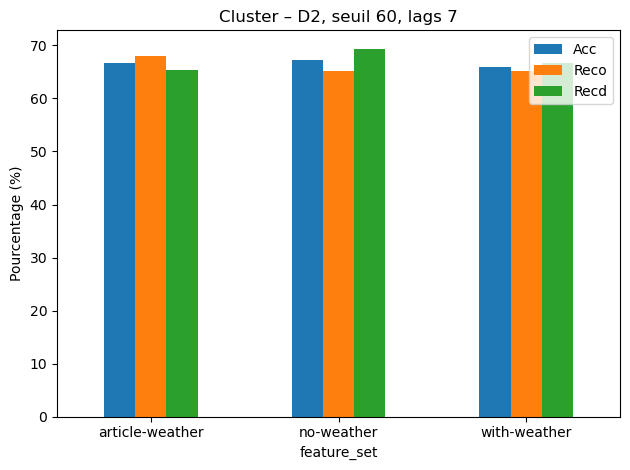

In [1]:


path = "Cluster_part-00000-82f1ce7a-8153-46e0-8285-e0243352bc8b-c000.csv"
df = pd.read_csv(path)

# extraire feature_set depuis la colonne comment
def extract_feature_set(c):
    import re
    m = re.search(r'featureSet=([a-zA-Z0-9\-]+)', str(c))
    if m: return m.group(1)
    m = re.search(r'\b(no-weather|with-weather|article-weather)\b', str(c))
    return m.group(1) if m else None

df["feature_set"] = df["comment"].apply(extract_feature_set)

sub = df[(df["dataset_id"]=="D2") &
         (df["delay_threshold_min"]==60) &
         (df["lags"]==7)]

summary = sub.groupby("feature_set").agg(
    Acc=("test_accuracy", "mean"),
    Recd=("test_recall_pos", "mean"),
    Reco=("test_specificity", "mean")
)

summary = summary[["Acc","Reco","Recd"]]  # ordre comme l'article

ax = summary.mul(100).plot(kind="bar")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Cluster – D2, seuil 60, lags 7")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

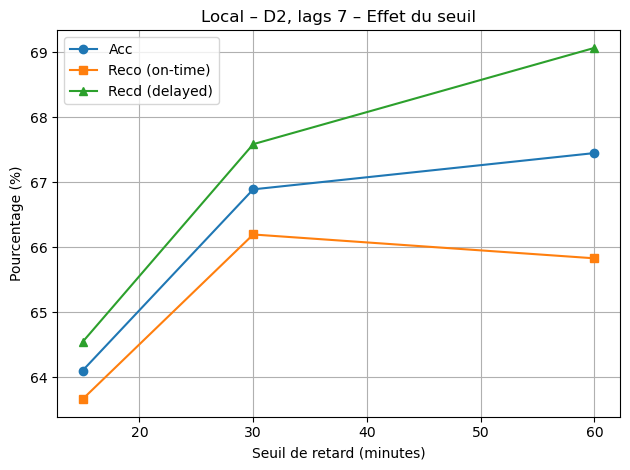

In [2]:
df = pd.read_csv("Local_1_part-00000-13421898-c004-45b8-86a9-0bc00436291f-c000.csv")

from re import search
def extract_feature_set(c):
    m = search(r'featureSet=([a-zA-Z0-9\-]+)', str(c))
    if m: return m.group(1)
    m = search(r'\b(no-weather|with-weather|article-weather)\b', str(c))
    return m.group(1) if m else None

df["feature_set"] = df["comment"].apply(extract_feature_set)

sub = df[(df["dataset_id"]=="D2") &
         (df["lags"]==7) &
         (df["feature_set"]=="no-weather")]

summary = sub.groupby("delay_threshold_min").agg(
    Acc=("test_accuracy","mean"),
    Recd=("test_recall_pos","mean"),
    Reco=("test_specificity","mean")
).sort_index()

x = summary.index.values
plt.plot(x, summary["Acc"]*100, marker="o", label="Acc")
plt.plot(x, summary["Reco"]*100, marker="s", label="Reco (on‑time)")
plt.plot(x, summary["Recd"]*100, marker="^", label="Recd (delayed)")
plt.xlabel("Seuil de retard (minutes)")
plt.ylabel("Pourcentage (%)")
plt.title("Local – D2, lags 7 – Effet du seuil")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()